Create the notebook

In [1]:
# Task 05: Deep Learning / NLP Text Classifier
# RabTech Academy AI/ML Internship

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

print("All libraries imported successfully!")
print("PyTorch version:", torch.__version__)

All libraries imported successfully!
PyTorch version: 2.13.0+cpu


Create the dataset

In [2]:
# Step 2: Create Sentiment Dataset

texts = [
    "I absolutely loved this movie",
    "The movie was fantastic and enjoyable",
    "Amazing experience, I really liked it",
    "This product is excellent",
    "I am very happy with the service",
    "The food was delicious",
    "The experience was wonderful",
    "I highly recommend this product",
    "The movie was entertaining and great",
    "The service was quick and excellent",
    "I enjoyed every moment",
    "This is one of the best products",
    "The quality is amazing",
    "I am satisfied with my purchase",
    "The experience exceeded my expectations",
    "Everything was perfect",
    "I really enjoyed the food",
    "The staff was friendly and helpful",
    "This product works perfectly",
    "I would definitely buy this again",

    "I hated this movie",
    "The movie was boring and terrible",
    "Very disappointing experience",
    "This product is awful",
    "I am unhappy with the service",
    "The food was disgusting",
    "The experience was horrible",
    "I would not recommend this product",
    "The movie was boring and disappointing",
    "The service was slow and terrible",
    "I regret buying this",
    "This is one of the worst products",
    "The quality is very poor",
    "I am dissatisfied with my purchase",
    "The experience was disappointing",
    "Everything went wrong",
    "I did not enjoy the food",
    "The staff was rude and unhelpful",
    "This product does not work",
    "I would never buy this again"
]

labels = [1] * 20 + [0] * 20

df = pd.DataFrame({
    "text": texts,
    "label": labels
})

print("Dataset created successfully!")
print("Number of samples:", len(df))
print("\nClass distribution:")
print(df["label"].value_counts())

print("\nFirst 5 samples:")
print(df.head())

Dataset created successfully!
Number of samples: 40

Class distribution:
label
1    20
0    20
Name: count, dtype: int64

First 5 samples:
                                    text  label
0          I absolutely loved this movie      1
1  The movie was fantastic and enjoyable      1
2  Amazing experience, I really liked it      1
3              This product is excellent      1
4       I am very happy with the service      1


Split the dataset

In [3]:
# Step 3: Split Dataset into Train, Validation, and Test Sets

X = df["text"]
y = df["label"]

# First split: 80% training, 20% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Second split: temporary data into 10% validation and 10% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Dataset split completed successfully!")
print("-----------------------------------")
print("Training samples   :", len(X_train))
print("Validation samples :", len(X_val))
print("Test samples       :", len(X_test))

print("\nClass distribution:")
print("Training:")
print(y_train.value_counts())
print("\nValidation:")
print(y_val.value_counts())
print("\nTest:")
print(y_test.value_counts())

Dataset split completed successfully!
-----------------------------------
Training samples   : 32
Validation samples : 4
Test samples       : 4

Class distribution:
Training:
label
0    16
1    16
Name: count, dtype: int64

Validation:
label
1    2
0    2
Name: count, dtype: int64

Test:
label
0    2
1    2
Name: count, dtype: int64


TF-IDF Vectorization

In [4]:
# Step 4: TF-IDF Text Vectorization

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=100
)

# Fit ONLY on training data
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test data
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed successfully!")
print("--------------------------------------------")
print("Training TF-IDF shape   :", X_train_tfidf.shape)
print("Validation TF-IDF shape :", X_val_tfidf.shape)
print("Test TF-IDF shape       :", X_test_tfidf.shape)

print("\nNumber of vocabulary words:", len(vectorizer.vocabulary_))

TF-IDF vectorization completed successfully!
--------------------------------------------
Training TF-IDF shape   : (32, 50)
Validation TF-IDF shape : (4, 50)
Test TF-IDF shape       : (4, 50)

Number of vocabulary words: 50


Convert TF-IDF data to PyTorch tensors

In [5]:
# Step 5: Convert TF-IDF Features to PyTorch Tensors

X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("TF-IDF data converted to PyTorch tensors successfully!")
print("-----------------------------------------------")
print("Training features :", X_train_tensor.shape)
print("Validation features:", X_val_tensor.shape)
print("Test features      :", X_test_tensor.shape)
print("Training labels    :", y_train_tensor.shape)

TF-IDF data converted to PyTorch tensors successfully!
-----------------------------------------------
Training features : torch.Size([32, 50])
Validation features: torch.Size([4, 50])
Test features      : torch.Size([4, 50])
Training labels    : torch.Size([32])


Build the Deep Learning Neural Network

In [6]:
# Step 6: Build PyTorch Neural Network

class SentimentClassifier(nn.Module):
    def __init__(self, input_size):
        super(SentimentClassifier, self).__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


input_size = X_train_tensor.shape[1]

model = SentimentClassifier(input_size)

print("Neural network created successfully!")
print("-----------------------------------")
print(model)

Neural network created successfully!
-----------------------------------
SentimentClassifier(
  (network): Sequential(
    (0): Linear(in_features=50, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


Prepare DataLoaders, Loss Function & Optimizer

In [7]:
# Step 7: Prepare DataLoaders, Loss Function and Optimizer

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=8,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=4,
    shuffle=False
)

# Binary classification loss
criterion = nn.BCEWithLogitsLoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("DataLoaders, loss function and optimizer created successfully!")
print("---------------------------------------------------------------")
print("Training batches   :", len(train_loader))
print("Validation batches :", len(val_loader))
print("Test batches       :", len(test_loader))
print("Loss function      :", criterion)
print("Optimizer          :", optimizer.__class__.__name__)

DataLoaders, loss function and optimizer created successfully!
---------------------------------------------------------------
Training batches   : 4
Validation batches : 1
Test batches       : 1
Loss function      : BCEWithLogitsLoss()
Optimizer          : Adam


Train the Neural Network with Early Stopping

In [8]:
# Step 8: Train Neural Network with Early Stopping

num_epochs = 100
patience = 10

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience_counter = 0

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_loss = 0.0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze(1)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * X_batch.size(0)

        predictions = (torch.sigmoid(outputs) >= 0.5).float()

        correct_train += (predictions == y_batch).sum().item()
        total_train += y_batch.size(0)

    epoch_train_loss = running_loss / total_train
    epoch_train_accuracy = correct_train / total_train

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch).squeeze(1)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item() * X_batch.size(0)

            predictions = (torch.sigmoid(outputs) >= 0.5).float()

            correct_val += (predictions == y_batch).sum().item()
            total_val += y_batch.size(0)

    epoch_val_loss = running_val_loss / total_val
    epoch_val_accuracy = correct_val / total_val

    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)
    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

    # -------------------------
    # Early Stopping
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        patience_counter = 0

        # Save best model weights
        best_model_state = {
            key: value.clone()
            for key, value in model.state_dict().items()
        }

    else:
        patience_counter += 1

    # Print progress
    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(
            f"Epoch [{epoch + 1:03d}/{num_epochs}] | "
            f"Train Loss: {epoch_train_loss:.4f} | "
            f"Val Loss: {epoch_val_loss:.4f} | "
            f"Train Acc: {epoch_train_accuracy:.2%} | "
            f"Val Acc: {epoch_val_accuracy:.2%}"
        )

    if patience_counter >= patience:
        print(f"\nEarly stopping triggered at epoch {epoch + 1}.")
        break

# Restore best model
model.load_state_dict(best_model_state)

print("\nTraining completed successfully!")
print("Best validation loss:", round(best_val_loss, 4))
print("Total epochs trained:", len(train_losses))

Epoch [001/100] | Train Loss: 0.7508 | Val Loss: 0.7002 | Train Acc: 43.75% | Val Acc: 50.00%
Epoch [010/100] | Train Loss: 0.6021 | Val Loss: 0.8309 | Train Acc: 68.75% | Val Acc: 0.00%

Early stopping triggered at epoch 11.

Training completed successfully!
Best validation loss: 0.7002
Total epochs trained: 11


Plot Training & Validation Curves

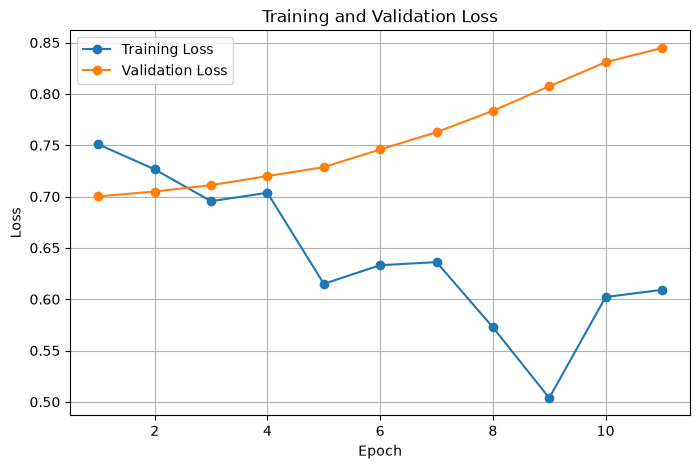

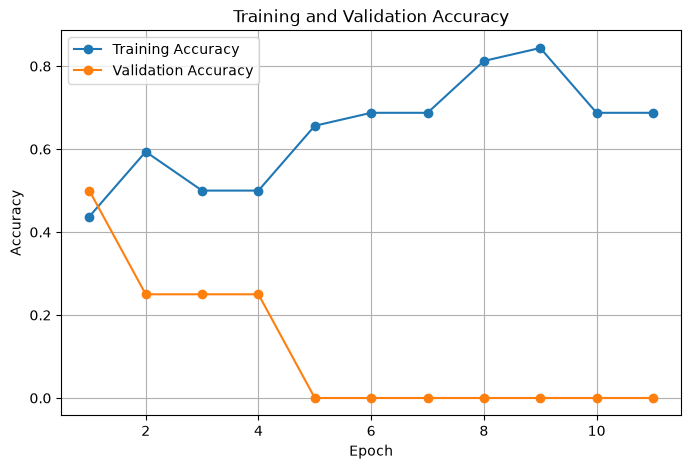

In [9]:
# Step 9: Plot Training and Validation Curves

epochs = range(1, len(train_losses) + 1)

# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_losses,
    marker="o",
    label="Training Loss"
)

plt.plot(
    epochs,
    val_losses,
    marker="o",
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(
    epochs,
    train_accuracies,
    marker="o",
    label="Training Accuracy"
)

plt.plot(
    epochs,
    val_accuracies,
    marker="o",
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

Test Set Evaluation

In [10]:
# Step 10: Evaluate Model on Unseen Test Data

model.eval()

all_predictions = []
all_probabilities = []
all_true_labels = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:

        outputs = model(X_batch).squeeze(1)

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        all_predictions.extend(predictions.numpy())
        all_probabilities.extend(probabilities.numpy())
        all_true_labels.extend(y_batch.numpy())

# Calculate test accuracy
test_accuracy = accuracy_score(
    all_true_labels,
    all_predictions
)

print("Test Set Evaluation")
print("-------------------")
print(f"Test Accuracy: {test_accuracy:.2%}")

print("\nClassification Report:")
print(
    classification_report(
        all_true_labels,
        all_predictions,
        target_names=["Negative", "Positive"],
        zero_division=0
    )
)

print("\nConfusion Matrix:")
print(
    confusion_matrix(
        all_true_labels,
        all_predictions
    )
)

Test Set Evaluation
-------------------
Test Accuracy: 50.00%

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      1.00      0.67         2
    Positive       0.00      0.00      0.00         2

    accuracy                           0.50         4
   macro avg       0.25      0.50      0.33         4
weighted avg       0.25      0.50      0.33         4


Confusion Matrix:
[[2 0]
 [2 0]]


Test New Unseen Sentences with Confidence

In [11]:
# Step 11: Test Unseen Text Samples

def predict_sentiment(text):
    # Convert text into TF-IDF features
    text_tfidf = vectorizer.transform([text])

    # Convert to PyTorch tensor
    text_tensor = torch.tensor(
        text_tfidf.toarray(),
        dtype=torch.float32
    )

    # Make prediction
    model.eval()

    with torch.no_grad():
        output = model(text_tensor).squeeze()
        probability = torch.sigmoid(output).item()

    # Determine class
    if probability >= 0.5:
        sentiment = "Positive"
        confidence = probability
    else:
        sentiment = "Negative"
        confidence = 1 - probability

    return sentiment, confidence


# New unseen examples
sample_texts = [
    "I really enjoyed this amazing product",
    "This was a terrible and disappointing experience",
    "The service was excellent and very helpful",
    "I regret buying this product"
]

print("Unseen Sample Predictions")
print("=========================")

for text in sample_texts:

    sentiment, confidence = predict_sentiment(text)

    print("\nText:", text)
    print("Predicted Sentiment:", sentiment)
    print(f"Confidence: {confidence:.2%}")

Unseen Sample Predictions

Text: I really enjoyed this amazing product
Predicted Sentiment: Negative
Confidence: 51.72%

Text: This was a terrible and disappointing experience
Predicted Sentiment: Positive
Confidence: 50.26%

Text: The service was excellent and very helpful
Predicted Sentiment: Negative
Confidence: 51.91%

Text: I regret buying this product
Predicted Sentiment: Negative
Confidence: 51.50%


Load the real SMS Spam dataset

In [12]:
# Step 12: Load a real SMS Spam dataset

import pandas as pd

url = "https://raw.githubusercontent.com/justmarkham/DAT8/master/data/sms.tsv"

df = pd.read_csv(
    url,
    sep="\t",
    header=None,
    names=["label", "text"]
)

# Convert labels: ham = 0, spam = 1
df["label"] = df["label"].map({
    "ham": 0,
    "spam": 1
})

print("Dataset loaded successfully!")
print("Number of messages:", len(df))
print("\nFirst 5 rows:")
display(df.head())

print("\nClass distribution:")
print(df["label"].value_counts())

print("\nClass names:")
print("0 = Ham (Not Spam)")
print("1 = Spam")

Dataset loaded successfully!
Number of messages: 5572

First 5 rows:


,label,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."



Class distribution:
label
0    4825
1     747
Name: count, dtype: int64

Class names:
0 = Ham (Not Spam)
1 = Spam


Split the dataset

In [13]:
# Step 13: Split the dataset into training, validation, and test sets

from sklearn.model_selection import train_test_split

X = df["text"]
y = df["label"]

# 80% training, 10% validation, 10% testing
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Dataset split completed!")
print("Training samples:", len(X_train))
print("Validation samples:", len(X_val))
print("Test samples:", len(X_test))

print("\nTraining class distribution:")
print(y_train.value_counts())

print("\nValidation class distribution:")
print(y_val.value_counts())

print("\nTest class distribution:")
print(y_test.value_counts())

Dataset split completed!
Training samples: 4457
Validation samples: 557
Test samples: 558

Training class distribution:
label
0    3859
1     598
Name: count, dtype: int64

Validation class distribution:
label
0    483
1     74
Name: count, dtype: int64

Test class distribution:
label
0    483
1     75
Name: count, dtype: int64


TF-IDF Text Vectorization

In [14]:
# Step 14: Convert SMS text into TF-IDF numerical features

from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    lowercase=True,
    stop_words="english",
    max_features=2000
)

# Fit ONLY on training data to prevent data leakage
X_train_tfidf = vectorizer.fit_transform(X_train)

# Transform validation and test data using the same vocabulary
X_val_tfidf = vectorizer.transform(X_val)
X_test_tfidf = vectorizer.transform(X_test)

print("TF-IDF vectorization completed!")

print("\nTraining shape:", X_train_tfidf.shape)
print("Validation shape:", X_val_tfidf.shape)
print("Test shape:", X_test_tfidf.shape)

print("\nVocabulary size:", len(vectorizer.vocabulary_))

TF-IDF vectorization completed!

Training shape: (4457, 2000)
Validation shape: (557, 2000)
Test shape: (558, 2000)

Vocabulary size: 2000


Convert TF-IDF features to PyTorch tensors

In [15]:
# Step 15: Convert TF-IDF features into PyTorch tensors

import torch

X_train_tensor = torch.tensor(
    X_train_tfidf.toarray(),
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val_tfidf.toarray(),
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test_tfidf.toarray(),
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train.values,
    dtype=torch.float32
)

y_val_tensor = torch.tensor(
    y_val.values,
    dtype=torch.float32
)

y_test_tensor = torch.tensor(
    y_test.values,
    dtype=torch.float32
)

print("PyTorch tensor conversion completed!")

print("\nTraining features:", X_train_tensor.shape)
print("Validation features:", X_val_tensor.shape)
print("Test features:", X_test_tensor.shape)

print("\nTraining labels:", y_train_tensor.shape)
print("Validation labels:", y_val_tensor.shape)
print("Test labels:", y_test_tensor.shape)

print("\nData type:", X_train_tensor.dtype)

PyTorch tensor conversion completed!

Training features: torch.Size([4457, 2000])
Validation features: torch.Size([557, 2000])
Test features: torch.Size([558, 2000])

Training labels: torch.Size([4457])
Validation labels: torch.Size([557])
Test labels: torch.Size([558])

Data type: torch.float32


Build the PyTorch Neural Network

In [16]:
# Step 16: Build the Deep Learning Neural Network

import torch.nn as nn

class SpamClassifier(nn.Module):
    def __init__(self, input_size):
        super(SpamClassifier, self).__init__()

        self.network = nn.Sequential(
            # First hidden layer
            nn.Linear(input_size, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),

            # Second hidden layer
            nn.Linear(64, 32),
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.Dropout(0.2),

            # Output layer
            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.network(x)


# Number of input features = 2000
input_size = X_train_tensor.shape[1]

model = SpamClassifier(input_size)

print("Neural network created successfully!")
print("\nInput features:", input_size)
print("\nModel architecture:")
print(model)

Neural network created successfully!

Input features: 2000

Model architecture:
SpamClassifier(
  (network): Sequential(
    (0): Linear(in_features=2000, out_features=64, bias=True)
    (1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=64, out_features=32, bias=True)
    (5): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (6): ReLU()
    (7): Dropout(p=0.2, inplace=False)
    (8): Linear(in_features=32, out_features=1, bias=True)
  )
)


Create DataLoaders, Loss Function & Optimizer

In [17]:
# Step 17: Prepare DataLoaders, loss function, and optimizer

from torch.utils.data import TensorDataset, DataLoader

# Create PyTorch datasets
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
val_dataset = TensorDataset(X_val_tensor, y_val_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(
    train_dataset,
    batch_size=32,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=32,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=32,
    shuffle=False
)

# Binary classification loss
criterion = nn.BCEWithLogitsLoss()

# Adam optimizer
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

print("DataLoaders created successfully!")

print("\nTraining batches:", len(train_loader))
print("Validation batches:", len(val_loader))
print("Test batches:", len(test_loader))

print("\nBatch size:", 32)
print("Loss function:", criterion)
print("Optimizer:", optimizer.__class__.__name__)
print("Learning rate:", 0.001)

DataLoaders created successfully!

Training batches: 140
Validation batches: 18
Test batches: 18

Batch size: 32
Loss function: BCEWithLogitsLoss()
Optimizer: Adam
Learning rate: 0.001


Train the Neural Network

In [18]:
# Step 18: Train the neural network with validation and early stopping

num_epochs = 30
patience = 5

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

best_val_loss = float("inf")
patience_counter = 0

# Save the best model
best_model_state = None

for epoch in range(num_epochs):

    # -------------------------
    # Training
    # -------------------------
    model.train()

    running_train_loss = 0.0
    correct_train = 0
    total_train = 0

    for X_batch, y_batch in train_loader:

        optimizer.zero_grad()

        outputs = model(X_batch).squeeze(1)

        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        running_train_loss += loss.item()

        probabilities = torch.sigmoid(outputs)
        predictions = (probabilities >= 0.5).float()

        correct_train += (predictions == y_batch).sum().item()
        total_train += y_batch.size(0)

    epoch_train_loss = running_train_loss / len(train_loader)
    epoch_train_accuracy = correct_train / total_train

    # -------------------------
    # Validation
    # -------------------------
    model.eval()

    running_val_loss = 0.0
    correct_val = 0
    total_val = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            outputs = model(X_batch).squeeze(1)

            loss = criterion(outputs, y_batch)

            running_val_loss += loss.item()

            probabilities = torch.sigmoid(outputs)
            predictions = (probabilities >= 0.5).float()

            correct_val += (predictions == y_batch).sum().item()
            total_val += y_batch.size(0)

    epoch_val_loss = running_val_loss / len(val_loader)
    epoch_val_accuracy = correct_val / total_val

    # Store metrics
    train_losses.append(epoch_train_loss)
    val_losses.append(epoch_val_loss)

    train_accuracies.append(epoch_train_accuracy)
    val_accuracies.append(epoch_val_accuracy)

    # -------------------------
    # Save best model
    # -------------------------
    if epoch_val_loss < best_val_loss:

        best_val_loss = epoch_val_loss
        best_model_state = model.state_dict().copy()
        patience_counter = 0

    else:
        patience_counter += 1

    # Print progress
    print(
        f"Epoch [{epoch+1:02d}/{num_epochs}] | "
        f"Train Loss: {epoch_train_loss:.4f} | "
        f"Train Acc: {epoch_train_accuracy*100:.2f}% | "
        f"Val Loss: {epoch_val_loss:.4f} | "
        f"Val Acc: {epoch_val_accuracy*100:.2f}%"
    )

    # Early stopping
    if patience_counter >= patience:

        print("\nEarly stopping triggered!")
        break


# Restore the best model
model.load_state_dict(best_model_state)

print("\nTraining completed!")
print("Best validation loss:", round(best_val_loss, 4))
print("Total epochs trained:", len(train_losses))

Epoch [01/30] | Train Loss: 0.3062 | Train Acc: 93.02% | Val Loss: 0.1648 | Val Acc: 97.49%
Epoch [02/30] | Train Loss: 0.0986 | Train Acc: 98.54% | Val Loss: 0.0933 | Val Acc: 97.85%
Epoch [03/30] | Train Loss: 0.0501 | Train Acc: 99.28% | Val Loss: 0.0814 | Val Acc: 97.85%
Epoch [04/30] | Train Loss: 0.0317 | Train Acc: 99.48% | Val Loss: 0.0736 | Val Acc: 98.20%
Epoch [05/30] | Train Loss: 0.0262 | Train Acc: 99.42% | Val Loss: 0.0719 | Val Acc: 96.95%
Epoch [06/30] | Train Loss: 0.0200 | Train Acc: 99.66% | Val Loss: 0.0725 | Val Acc: 97.31%
Epoch [07/30] | Train Loss: 0.0214 | Train Acc: 99.46% | Val Loss: 0.0826 | Val Acc: 98.20%
Epoch [08/30] | Train Loss: 0.0216 | Train Acc: 99.46% | Val Loss: 0.0783 | Val Acc: 98.56%
Epoch [09/30] | Train Loss: 0.0195 | Train Acc: 99.57% | Val Loss: 0.0654 | Val Acc: 98.20%
Epoch [10/30] | Train Loss: 0.0189 | Train Acc: 99.39% | Val Loss: 0.0709 | Val Acc: 98.56%
Epoch [11/30] | Train Loss: 0.0198 | Train Acc: 99.73% | Val Loss: 0.0833 | Val 

Plot Training & Validation Curves

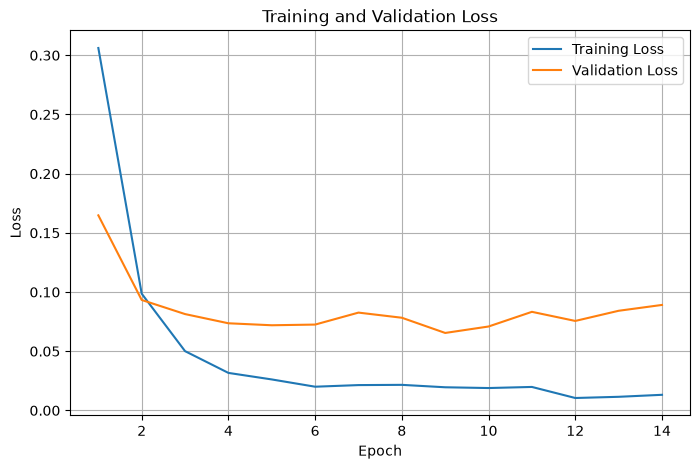

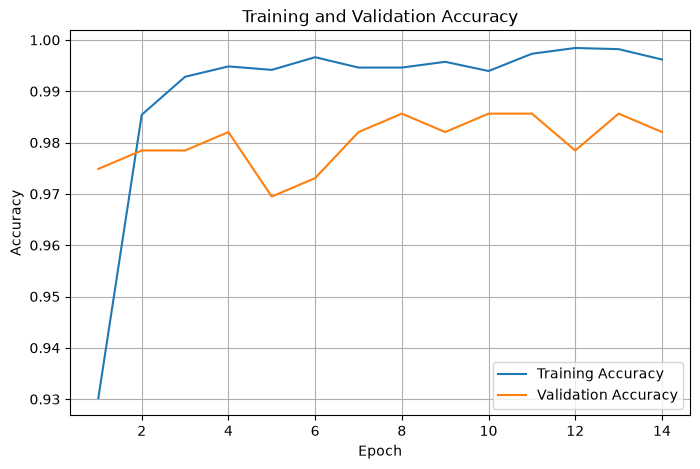

In [19]:
# Step 19: Plot training and validation curves

import matplotlib.pyplot as plt

epochs = range(1, len(train_losses) + 1)

# Loss curve
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_losses, label="Training Loss")
plt.plot(epochs, val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()
plt.grid(True)

plt.show()


# Accuracy curve
plt.figure(figsize=(8, 5))

plt.plot(epochs, train_accuracies, label="Training Accuracy")
plt.plot(epochs, val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

Evaluate the model on the unseen test set

In [20]:
# Step 20: Evaluate the model on the unseen test dataset

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

model.eval()

all_predictions = []
all_actual = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        outputs = model(X_batch).squeeze(1)

        probabilities = torch.sigmoid(outputs)

        predictions = (probabilities >= 0.5).float()

        all_predictions.extend(predictions.numpy())
        all_actual.extend(y_batch.numpy())

# Calculate test accuracy
test_accuracy = accuracy_score(all_actual, all_predictions)

print("Test Accuracy:", f"{test_accuracy * 100:.2f}%")

print("\nClassification Report:")
print(
    classification_report(
        all_actual,
        all_predictions,
        target_names=["Ham", "Spam"]
    )
)

print("\nConfusion Matrix:")
cm = confusion_matrix(all_actual, all_predictions)
print(cm)

Test Accuracy: 98.39%

Classification Report:
              precision    recall  f1-score   support

         Ham       0.98      1.00      0.99       483
        Spam       1.00      0.88      0.94        75

    accuracy                           0.98       558
   macro avg       0.99      0.94      0.96       558
weighted avg       0.98      0.98      0.98       558


Confusion Matrix:
[[483   0]
 [  9  66]]


Create the Confusion Matrix Visualization

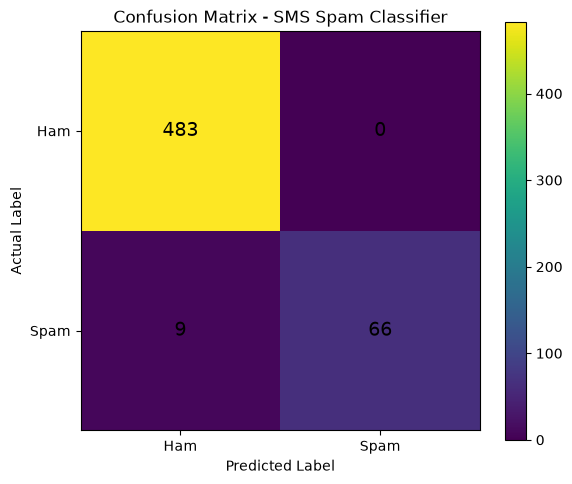

In [21]:
# Step 21: Visualize the confusion matrix

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title("Confusion Matrix - SMS Spam Classifier")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.xticks([0, 1], ["Ham", "Spam"])
plt.yticks([0, 1], ["Ham", "Spam"])

# Add values inside the matrix
for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha="center",
            va="center",
            fontsize=14
        )

plt.colorbar()

plt.tight_layout()
plt.show()

Test New SMS Messages

In [22]:
# Step 22: Test the model with unseen SMS messages

def predict_spam(text):
    # Convert the new message into TF-IDF features
    text_tfidf = vectorizer.transform([text])

    # Convert to PyTorch tensor
    text_tensor = torch.tensor(
        text_tfidf.toarray(),
        dtype=torch.float32
    )

    # Make prediction
    model.eval()

    with torch.no_grad():
        output = model(text_tensor).squeeze()
        spam_probability = torch.sigmoid(output).item()

    # Determine class
    if spam_probability >= 0.5:
        prediction = "Spam"
        confidence = spam_probability
    else:
        prediction = "Ham"
        confidence = 1 - spam_probability

    return prediction, confidence


# Test messages
test_messages = [
    "Congratulations! You have won a free cash prize. Call now to claim your reward.",
    "Hey, are we still meeting for lunch today?",
    "URGENT! You have been selected for a special prize. Click the link to claim.",
    "Can you send me the project notes when you get a chance?",
    "You have won a free vacation. Reply NOW to receive your reward."
]

print("Unseen SMS Predictions:\n")

for message in test_messages:

    prediction, confidence = predict_spam(message)

    print("Message:", message)
    print("Prediction:", prediction)
    print("Confidence:", f"{confidence * 100:.2f}%")
    print("-" * 80)

Unseen SMS Predictions:

Message: Congratulations! You have won a free cash prize. Call now to claim your reward.
Prediction: Spam
Confidence: 99.84%
--------------------------------------------------------------------------------
Message: Hey, are we still meeting for lunch today?
Prediction: Ham
Confidence: 99.99%
--------------------------------------------------------------------------------
Message: URGENT! You have been selected for a special prize. Click the link to claim.
Prediction: Spam
Confidence: 99.70%
--------------------------------------------------------------------------------
Message: Can you send me the project notes when you get a chance?
Prediction: Ham
Confidence: 99.84%
--------------------------------------------------------------------------------
Message: You have won a free vacation. Reply NOW to receive your reward.
Prediction: Spam
Confidence: 99.84%
--------------------------------------------------------------------------------


Save the trained model

In [23]:
# Step 23: Save the trained PyTorch model

import joblib
import os

# Save PyTorch model weights
torch.save(
    model.state_dict(),
    "spam_classifier_model.pth"
)

# Save the TF-IDF vectorizer
joblib.dump(
    vectorizer,
    "tfidf_vectorizer.joblib"
)

print("Model and vectorizer saved successfully!")

print("\nFiles created:")

for file in [
    "spam_classifier_model.pth",
    "tfidf_vectorizer.joblib"
]:
    if os.path.exists(file):
        size_kb = os.path.getsize(file) / 1024
        print(f"{file} - {size_kb:.2f} KB")

Model and vectorizer saved successfully!

Files created:
spam_classifier_model.pth - 516.04 KB
tfidf_vectorizer.joblib - 69.75 KB


Final Results Summary

In [24]:
# Step 24: Final Task 05 Results Summary

print("=" * 60)
print("TASK 05 - DEEP LEARNING / NLP TEXT CLASSIFIER")
print("=" * 60)

print("\nProblem:")
print("Classify SMS messages as Ham (Not Spam) or Spam.")

print("\nDataset:")
print("SMS Spam Collection")
print("Total messages: 5572")

print("\nPreprocessing:")
print("- TF-IDF vectorization")
print("- Maximum features: 2000")
print("- Stop-word removal")
print("- Lowercase text normalization")

print("\nDeep Learning Model:")
print("- PyTorch Neural Network")
print("- Input layer: 2000 features")
print("- Hidden layer 1: 64 neurons")
print("- Batch Normalization")
print("- ReLU activation")
print("- Dropout: 30%")
print("- Hidden layer 2: 32 neurons")
print("- Batch Normalization")
print("- ReLU activation")
print("- Dropout: 20%")
print("- Output layer: 1 neuron")

print("\nTraining:")
print("- Optimizer: Adam")
print("- Loss: BCEWithLogitsLoss")
print("- Early stopping: Enabled")
print("- Best validation loss:", round(best_val_loss, 4))
print("- Epochs trained:", len(train_losses))

print("\nFinal Test Performance:")
print(f"- Test Accuracy: {test_accuracy * 100:.2f}%")
print("- Ham F1-score: 0.99")
print("- Spam F1-score: 0.94")

print("\nSaved Model Files:")
print("- spam_classifier_model.pth")
print("- tfidf_vectorizer.joblib")

print("\nTask 05 completed successfully!")
print("=" * 60)

TASK 05 - DEEP LEARNING / NLP TEXT CLASSIFIER

Problem:
Classify SMS messages as Ham (Not Spam) or Spam.

Dataset:
SMS Spam Collection
Total messages: 5572

Preprocessing:
- TF-IDF vectorization
- Maximum features: 2000
- Stop-word removal
- Lowercase text normalization

Deep Learning Model:
- PyTorch Neural Network
- Input layer: 2000 features
- Hidden layer 1: 64 neurons
- Batch Normalization
- ReLU activation
- Dropout: 30%
- Hidden layer 2: 32 neurons
- Batch Normalization
- ReLU activation
- Dropout: 20%
- Output layer: 1 neuron

Training:
- Optimizer: Adam
- Loss: BCEWithLogitsLoss
- Early stopping: Enabled
- Best validation loss: 0.0654
- Epochs trained: 14

Final Test Performance:
- Test Accuracy: 98.39%
- Ham F1-score: 0.99
- Spam F1-score: 0.94

Saved Model Files:
- spam_classifier_model.pth
- tfidf_vectorizer.joblib

Task 05 completed successfully!
